In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import os
from pathlib import Path
import scienceplots

In [11]:
# Cell 2: Load all CSV files from folder
#folder_path = r"C:\Arjun\Thesis\data\20200421_170039-sunset1\filtered chunks"  # Change this to your folder path
folder_path = r"C:\Arjun\Thesis\data\20200421_170039-sunset1\filtered chunks\un-normalised"
window_size = 30  # seconds
csv_files = glob.glob(folder_path + "/filtered_events_batch_*.csv")
csv_files.sort()

print(f"Found {len(csv_files)} files")

Found 162 files


In [12]:
# Cell 3: Find global time range without loading all data
t_min = float('inf')
t_max = float('-inf')

for file in csv_files:
    # Read only timestamp column
    df = pd.read_csv(file, usecols=['timestamp'])
    
    # Convert to seconds if needed (check first file)
    
  
    t_file_min = df['timestamp'].min()
    t_file_max = df['timestamp'].max()
    
    t_min = min(t_min, t_file_min)
    t_max = max(t_max, t_file_max)
    
    # Free memory
    del df

duration = t_max - t_min
print(f"Global time range: {t_min:.2f} to {t_max:.2f} seconds")
print(f"Total duration: {duration/60:.2f} minutes")

Global time range: 1587452584.62 to 1587452828.27 seconds
Total duration: 4.06 minutes


In [13]:
# Cell 4: Create bins and initialize counters
# Create bins for all 30-second windows
bins = np.arange(t_min, t_max + window_size, window_size)
events_per_window = np.zeros(len(bins) - 1, dtype=np.int64)

print(f"Number of 30-second windows: {len(events_per_window)}")

Number of 30-second windows: 9


In [14]:
# Cell 5: Process each file and count events per window
# Will be set in Cell 3

for file_idx, file in enumerate(csv_files):
    # Read timestamp column only
    df = pd.read_csv(file, usecols=['timestamp'])
    
    # Convert to seconds if needed (check first file)
    

    timestamps = df['timestamp'].values
    
    # Count events in each bin for this file
    file_counts, _ = np.histogram(timestamps, bins=bins)
    
    # Add to total counts
    events_per_window += file_counts
    
    # Free memory
    del df, timestamps, file_counts
    
    # Print progress
    if (file_idx + 1) % 10 == 0:
        print(f"Processed {file_idx + 1}/{len(csv_files)} files")

print(f"\nProcessed all {len(csv_files)} files")
print(f"Total events: {events_per_window.sum():,}")

Processed 10/162 files
Processed 20/162 files
Processed 30/162 files
Processed 40/162 files
Processed 50/162 files
Processed 60/162 files
Processed 70/162 files
Processed 80/162 files
Processed 90/162 files
Processed 100/162 files
Processed 110/162 files
Processed 120/162 files
Processed 130/162 files
Processed 140/162 files
Processed 150/162 files
Processed 160/162 files

Processed all 162 files
Total events: 630,282


In [15]:
window_centers = (bins[:-1] + bins[1:]) / 2

# Convert to minutes from start
window_centers_minutes = (window_centers - t_min) / 60

In [16]:
# Cell 6: Calculate window centers and averages
window_centers = (bins[:-1] + bins[1:]) / 2

# Convert to minutes from start
window_centers_minutes = (window_centers - t_min) / 60

# Calculate regular average (single value)
overall_avg = np.mean(events_per_window)

# Convert to 100Ks
events_per_window_100k = events_per_window / 100000
overall_avg_100k = overall_avg / 100000

print(f"Average events per 30s window: {overall_avg:.2f} ({overall_avg_100k:.2f} x 100K)")
print(f"Recording duration: {(t_max - t_min)/60:.2f} minutes")

Average events per 30s window: 70031.33 (0.70 x 100K)
Recording duration: 4.06 minutes


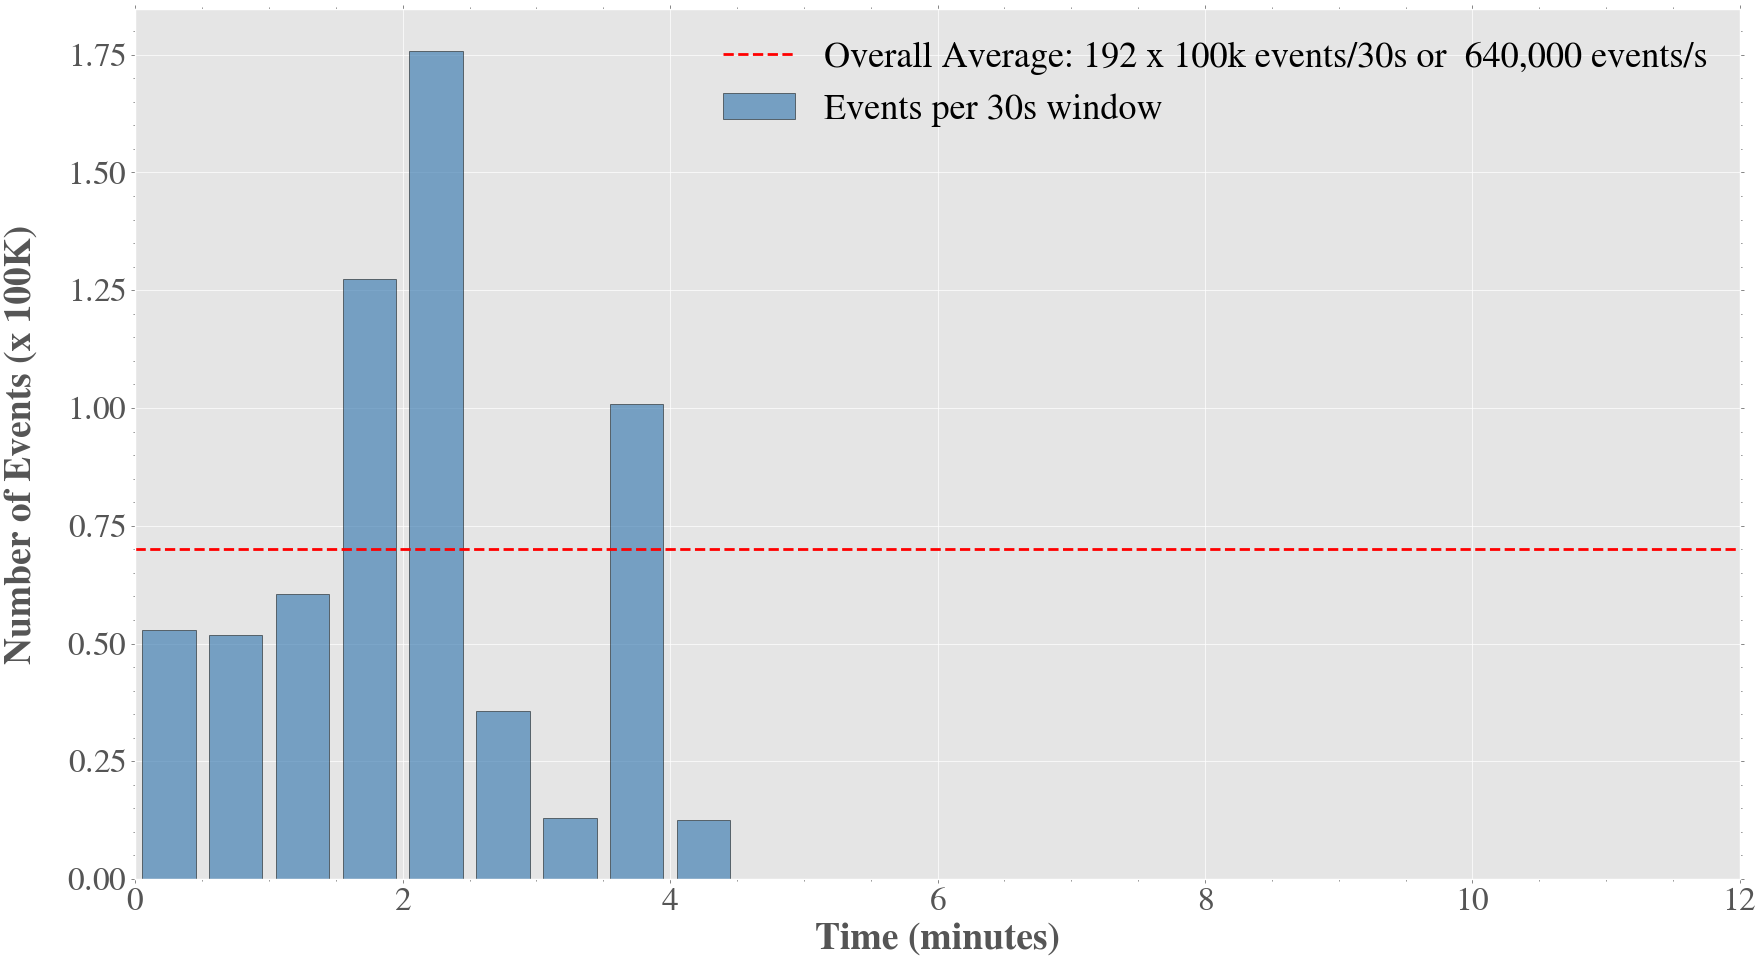

In [17]:
# Cell 7: Plot events per 30-second window with average line
plt.style.use(['science','no-latex'])
plt.style.use('ggplot')
plt.figure(figsize=(18, 10))
plt.rcParams.update({'font.size': 16})
# Plot events per window (in 100Ks, time in minutes)
plt.bar(window_centers_minutes, events_per_window_100k, width=(window_size/60)*0.8, 
        alpha=0.7, color='steelblue', edgecolor='black', label='Events per 30s window')

# Add horizontal line for overall average
#plt.axhline(y=overall_avg_100k, color='r', linestyle='--', linewidth=2, 
            #label=f'Overall Average: {overall_avg_100k:.1f} x 100K events/30s')
plt.axhline(y=overall_avg_100k, color='r', linestyle='--', linewidth=2, 
            label=f'Overall Average: 192 x 100k events/30s or  640,000 events/s')


plt.xlabel('Time (minutes)', fontsize=27,fontweight='bold')
plt.ylabel('Number of Events (x 100K)', fontsize=27, labelpad=20,fontweight='bold')
#plt.title('Events in 30-Second Windows Over Time', fontsize=14)
plt.legend(loc='best',fontsize=26)
plt.xticks(fontsize=24)
plt.yticks(fontsize=24)

#plt.grid(True, alpha=0.3)

# Set x-axis limits from 0 to 12 minutes
plt.xlim(0, 12)
plt.tight_layout()
plt.show()

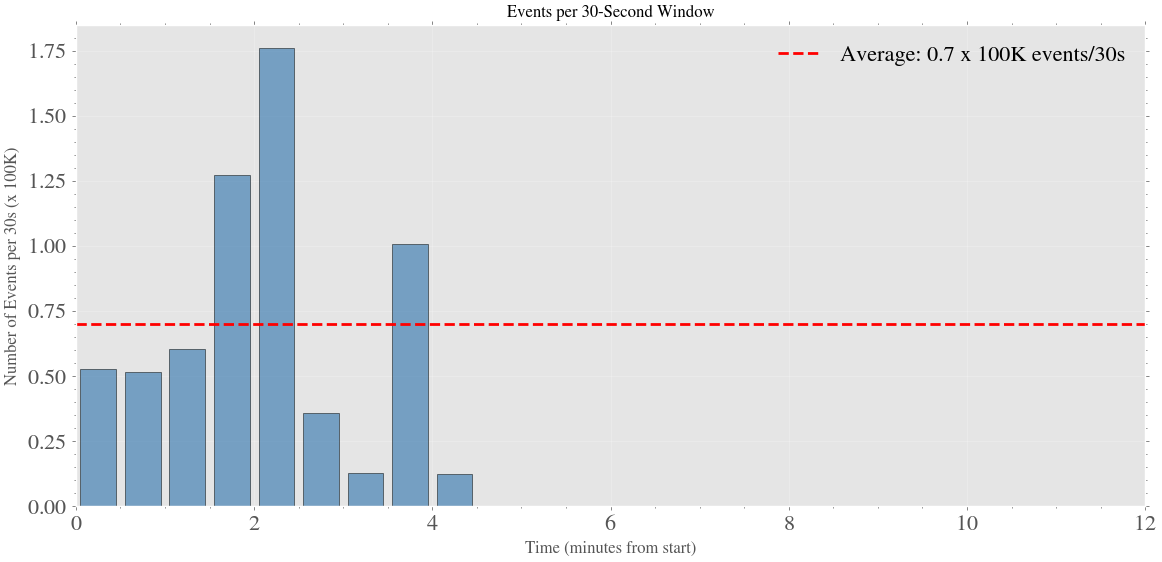

In [18]:
# Cell 8: (Optional) Simpler view - just the bar chart
plt.figure(figsize=(12, 6))

plt.bar(window_centers_minutes, events_per_window_100k, width=(window_size/60)*0.8, 
        alpha=0.7, color='steelblue', edgecolor='black')
plt.axhline(y=overall_avg_100k, color='r', linestyle='--', linewidth=2, 
            label=f'Average: {overall_avg_100k:.1f} x 100K events/30s')

plt.xlabel('Time (minutes from start)', fontsize=12)
plt.ylabel(f'Number of Events per {window_size}s (x 100K)', fontsize=12)
plt.title('Events per 30-Second Window', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xlim(0, 12)
plt.legend()
plt.tight_layout()
plt.show()

NameError: name 'cumulative_avg_100k' is not defined

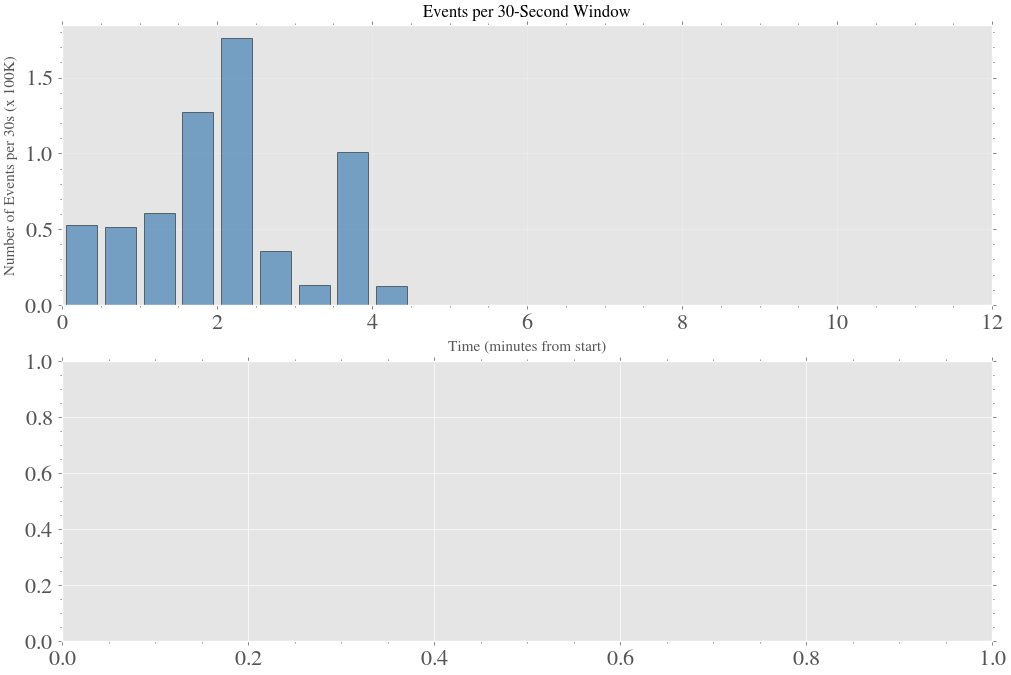

In [19]:
# Cell 8: (Optional) Additional plot - events per window
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Events per window (in 100Ks, time in minutes)
ax1.bar(window_centers_minutes, events_per_window_100k, width=(window_size/60)*0.8, 
        alpha=0.7, color='steelblue', edgecolor='black')
ax1.set_xlabel('Time (minutes from start)', fontsize=11)
ax1.set_ylabel(f'Number of Events per {window_size}s (x 100K)', fontsize=11)
ax1.set_title('Events per 30-Second Window', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 12)

# Plot 2: Cumulative average (in 100Ks, time in minutes)
ax2.plot(window_centers_minutes, cumulative_avg_100k, 'g-', linewidth=2)
ax2.set_xlabel('Time (minutes from start)', fontsize=11)
ax2.set_ylabel(f'Cumulative Average Events per {window_size}s (x 100K)', fontsize=11)
ax2.set_title('Cumulative Average Over Time', fontsize=12)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 12)

plt.tight_layout()
plt.show()